In [1]:
# Short, Karen C. 2017. Dados de ocorrência de incêndios florestais espaciais para os Estados Unidos, 1992-2015 [FPA_FOD_20170508]. 4a Edição. Fort Collins, CO: Arquivo de Dados de Pesquisa do Serviço Florestal. https://doi.org/10.2737/RDS-2013-0009.4

import sqlite3
import pandas as pd
from sklearn.model_selection import train_test_split

# O dataset original esta em SQLite. Esta consulta carrega apenas as colunas usadas
# no experimento para reduzir memoria e manter o notebook mais direto.
conn = sqlite3.connect("./wildfires_dataset.sqlite")

query = """
SELECT
    FIRE_YEAR,
    DISCOVERY_DOY,
    STAT_CAUSE_DESCR,
    FIRE_SIZE,
    FIRE_SIZE_CLASS,
    LATITUDE,
    LONGITUDE,
    STATE
FROM Fires
"""

df = pd.read_sql_query(query, conn)
conn.close()

# === Configurações e Hiperparâmetros ===

# A variavel alvo e a classe de tamanho do incendio, de A (menor) ate G (maior).
TARGET = "FIRE_SIZE_CLASS"

# A modelagem usa ate 20 mil registros por classe no recorte dos EUA continentais.
# Classes com menos registros usam o maximo disponivel depois do filtro geografico.
SAMPLES_PER_CLASS = 20_000
TEST_SIZE_RATIO = 0.2
RANDOM_STATE = 42
CONTINENTAL_LATITUDE_RANGE = (24, 50)
CONTINENTAL_LONGITUDE_RANGE = (-125, -66)
FIRE_CLASS_ORDER = list("ABCDEFG")

# Cada entrada testa uma hipotese diferente sobre quais informacoes ajudam a prever
# a classe de tamanho do incendio. FIRE_SIZE nao entra nas features para evitar
# vazamento direto da resposta, ja que FIRE_SIZE_CLASS deriva do tamanho final.
FEATURES = {
    "localizacao": ["LATITUDE", "LONGITUDE"],
    "localizacao_estado_ano_diaAno": ["LATITUDE", "LONGITUDE", "STATE", "FIRE_YEAR", "DISCOVERY_DOY"],
    "localizacao_estado_causa": ["LATITUDE", "LONGITUDE", "STATE", "DISCOVERY_DOY", "STAT_CAUSE_DESCR"],
    "tempo": ["FIRE_YEAR", "DISCOVERY_DOY"],
    "causa": ["STAT_CAUSE_DESCR"],
    "estado": ["STATE"],
    "localizacao_tempo": ["LATITUDE", "LONGITUDE", "FIRE_YEAR", "DISCOVERY_DOY"],
    "localizacao_causa": ["LATITUDE", "LONGITUDE", "STAT_CAUSE_DESCR"],
    "localizacao_estado": ["LATITUDE", "LONGITUDE", "STATE"],
    "causa_estado": ["STAT_CAUSE_DESCR", "STATE"],
    "todos_sem_fire_size": ["FIRE_YEAR", "DISCOVERY_DOY", "STAT_CAUSE_DESCR", "LATITUDE", "LONGITUDE", "STATE"],
}

all_feature_columns = sorted(set().union(*FEATURES.values()))
feature_df = df[[TARGET, *all_feature_columns]].dropna().copy()
feature_df = feature_df[feature_df[TARGET].isin(FIRE_CLASS_ORDER)]
feature_df = feature_df[
    feature_df["LATITUDE"].between(*CONTINENTAL_LATITUDE_RANGE)
    & feature_df["LONGITUDE"].between(*CONTINENTAL_LONGITUDE_RANGE)
].copy()

# Balanceia a base: cada classe contribui com ate SAMPLES_PER_CLASS registros.
# Isso reduz o dominio das classes A/B e torna a comparacao entre classes mais justa.
feature_sample = pd.concat(
    [
        class_df.sample(
            n=min(len(class_df), SAMPLES_PER_CLASS),
            random_state=RANDOM_STATE,
        )
        for _, class_df in feature_df.groupby(TARGET, sort=True)
    ],
    ignore_index=True,
).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

sample_distribution = feature_sample[TARGET].value_counts().reindex(FIRE_CLASS_ORDER, fill_value=0)
print("Distribuicao da amostra por classe:")
display(sample_distribution.rename("registros_amostra").to_frame())

train_df, test_df = train_test_split(
    feature_sample,
    test_size=TEST_SIZE_RATIO,
    random_state=RANDOM_STATE,
    stratify=feature_sample[TARGET],
)

y_train = train_df[TARGET]
y_test = test_df[TARGET]

split_distribution = pd.DataFrame(
    {
        "registros_amostra": sample_distribution,
        "registros_treino": y_train.value_counts().reindex(FIRE_CLASS_ORDER, fill_value=0),
        "registros_teste": y_test.value_counts().reindex(FIRE_CLASS_ORDER, fill_value=0),
    }
)
split_distribution["percentual_treino"] = (
    split_distribution["registros_treino"] / split_distribution["registros_treino"].sum() * 100
).round(2)
split_distribution["percentual_teste"] = (
    split_distribution["registros_teste"] / split_distribution["registros_teste"].sum() * 100
).round(2)
split_distribution.index.name = "classe"
print("Distribuicao estratificada por classe em treino e teste:")
display(split_distribution)

# ---=== Funções e Métodos ===---


def create_pipeline(feature_columns, type_model):
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.compose import ColumnTransformer
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.neural_network import MLPClassifier

    # Colunas numericas recebem padronizacao; colunas categoricas viram variaveis
    # binariais para que todos os modelos consigam processa-las.
    numeric_columns = train_df[feature_columns].select_dtypes(include="number").columns.tolist()
    categorical_columns = [col for col in feature_columns if col not in numeric_columns]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_columns),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ]
    )

    # KNN representa o metodo da Parte 1; Random Forest e MLP representam metodos
    # da Parte 2 definidos para a comparacao do trabalho.
    type_model_map = {
        "knn": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        "rf": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        "mlp": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            max_iter=100,
            early_stopping=True,
            random_state=42,
        ),
    }

    if type_model not in type_model_map:
        raise ValueError(f"Modelo inválido: {type_model}. Use: {list(type_model_map.keys())}")

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", type_model_map[type_model]),
        ]
    )


def fit_accuracy_cm_f1(model, feature_columns, y_train_input=None, y_test_input=None):
    from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

    target_train = y_train if y_train_input is None else y_train_input
    target_test = y_test if y_test_input is None else y_test_input

    # Treina o pipeline completo e avalia sempre no mesmo conjunto de teste.
    model.fit(train_df[feature_columns], target_train)
    y_pred = model.predict(test_df[feature_columns])

    accuracy = accuracy_score(target_test, y_pred)
    f1 = f1_score(target_test, y_pred, average="weighted")
    labels = model.classes_.tolist()
    cm = confusion_matrix(target_test, y_pred, labels=labels)

    return accuracy, cm, f1, labels


def show_feature_loading_status(feature_names, current_index, elapsed_times=None):
    from IPython.display import clear_output

    if elapsed_times is None:
        elapsed_times = {}

    clear_output(wait=True)
    print("Progresso por conjunto de features:")
    print()

    for idx, feature_name in enumerate(feature_names):
        if idx < current_index:
            elapsed = elapsed_times.get(feature_name)
            if elapsed is None:
                status = "✅"
            else:
                status = f"✅ ({elapsed:.2f}s)"
        elif idx == current_index:
            status = "🟡"
        else:
            status = "..."

        print(f"{feature_name} {status}")


def show_model_ranking(results):
    import matplotlib.pyplot as plt
    import seaborn as sns

    ranking_df = (
        pd.DataFrame(results)
        .sort_values(["accuracy", "f1_score"], ascending=False)
        .reset_index(drop=True)
    )
    ranking_df.insert(0, "ranking", ranking_df.index + 1)

    ranking_table = ranking_df[["ranking", "feature_set", "accuracy", "f1_score", "tempo_segundos"]].copy()
    ranking_table = ranking_table.rename(columns={"tempo_segundos": "tempo"})
    ranking_table["accuracy"] = ranking_table["accuracy"].map(lambda value: f"{value:.2%}")
    ranking_table["f1_score"] = ranking_table["f1_score"].map(lambda value: f"{value:.4f}")
    ranking_table["tempo"] = ranking_table["tempo"].map(lambda value: f"{value:.2f}s")

    display(ranking_table)

    print()
    print("Matriz de confusão por ranking:")
    print()
    for _, row in ranking_df.iterrows():
        print(f"Ranking {int(row['ranking'])} - {row['feature_set']} ({row['tempo_segundos']:.2f}s)")
        cm_df = pd.DataFrame(
            row["confusion_matrix"],
            index=row["labels"],
            columns=row["labels"],
        )

        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm_df,
            annot=True,
            fmt="d",
            cmap="YlOrRd",
            cbar=True,
            linewidths=0.3,
            linecolor="white",
        )
        plt.title(f"Confusion Matrix - {row['feature_set']}")
        plt.xlabel("Predito")
        plt.ylabel("Real")
        plt.tight_layout()
        plt.show()

    return ranking_df


def save_best_confusion_matrix(ranking_df, title, output_path):
    import matplotlib.pyplot as plt
    import seaborn as sns

    best = ranking_df.iloc[0]
    cm_df = pd.DataFrame(
        best["confusion_matrix"],
        index=best["labels"],
        columns=best["labels"],
    )

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm_df,
        annot=True,
        fmt="d",
        cmap="YlOrRd",
        cbar=True,
        linewidths=0.3,
        linecolor="white",
    )
    plt.title(f"{title} - melhor conjunto: {best['feature_set']}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.close()


def save_model_comparison(ranking_frames, output_path="ComparacaoModelos.png"):
    import matplotlib.pyplot as plt

    comparison_rows = []
    for model_name, ranking_df in ranking_frames.items():
        best = ranking_df.iloc[0]
        comparison_rows.append(
            {
                "modelo": model_name,
                "accuracy": best["accuracy"],
                "f1_score": best["f1_score"],
                "feature_set": best["feature_set"],
            }
        )

    comparison_df = pd.DataFrame(comparison_rows)
    fig, ax = plt.subplots(figsize=(9, 5))
    x_positions = range(len(comparison_df))
    width = 0.35

    ax.bar([x - width / 2 for x in x_positions], comparison_df["accuracy"], width, label="Acuracia")
    ax.bar([x + width / 2 for x in x_positions], comparison_df["f1_score"], width, label="F1-score ponderado")
    ax.set_xticks(list(x_positions))
    ax.set_xticklabels(comparison_df["modelo"])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Pontuacao")
    ax.set_title("Comparacao dos melhores resultados por modelo")
    ax.legend()
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.35)

    for idx, row in comparison_df.iterrows():
        ax.text(idx, max(row["accuracy"], row["f1_score"]) + 0.02, row["feature_set"], ha="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()

    return comparison_df


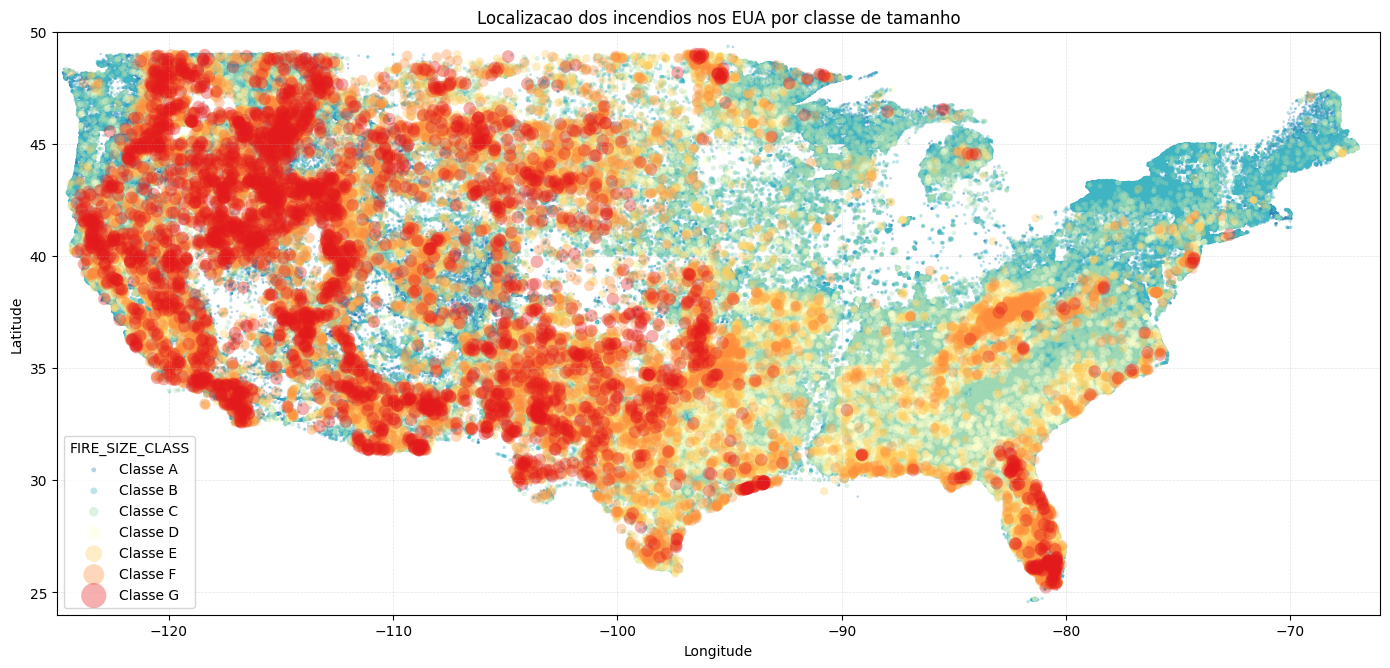

In [2]:
import matplotlib.pyplot as plt

fire_class_order = list("ABCDEFG")

# A = menor incendio, G = maior incendio. O valor controla o tamanho do ponto no scatter.
size_by_class = {
    "A": 3,
    "B": 6,
    "C": 12,
    "D": 22,
    "E": 36,
    "F": 56,
    "G": 82,
}

color_by_class = {
    "A": "#2c7fb8",
    "B": "#41b6c4",
    "C": "#a1dab4",
    "D": "#ffffcc",
    "E": "#fecc5c",
    "F": "#fd8d3c",
    "G": "#e31a1c",
}

plot_df = df.dropna(subset=["LATITUDE", "LONGITUDE", "FIRE_SIZE_CLASS"]).copy()
plot_df = plot_df[plot_df["FIRE_SIZE_CLASS"].isin(fire_class_order)]

# Mantem o mapa focado nos EUA continentais. Remova este filtro para incluir AK/HI/territorios.
plot_df = plot_df[
    plot_df["LATITUDE"].between(24, 50)
    & plot_df["LONGITUDE"].between(-125, -66)
]

fig, ax = plt.subplots(figsize=(14, 8))

for fire_class in fire_class_order:
    class_df = plot_df[plot_df["FIRE_SIZE_CLASS"] == fire_class]

    ax.scatter(
        class_df["LONGITUDE"],
        class_df["LATITUDE"],
        s=size_by_class[fire_class],
        color=color_by_class[fire_class],
        alpha=0.35,
        edgecolors="none",
        label=f"Classe {fire_class}",
    )

ax.set_title("Localizacao dos incendios nos EUA por classe de tamanho")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)
ax.legend(title="FIRE_SIZE_CLASS", markerscale=2, frameon=True)

plt.tight_layout()
plt.savefig("MapaIncendiosPorClasse.png", dpi=160, bbox_inches="tight")
plt.show()


Progresso por conjunto de features:

localizacao ✅ (0.27s)
localizacao_estado_ano_diaAno ✅ (9.64s)
localizacao_estado_causa ✅ (9.07s)
tempo ✅ (0.13s)
causa ✅ (5.08s)
estado ✅ (4.19s)
localizacao_tempo ✅ (0.14s)
localizacao_causa ✅ (9.14s)
localizacao_estado ✅ (8.98s)
causa_estado ✅ (5.92s)
todos_sem_fire_size ✅ (9.72s)


,ranking,feature_set,accuracy,f1_score,tempo
0,1,localizacao_causa,57.87%,0.5553,9.14s
1,2,localizacao_estado_causa,57.61%,0.5516,9.07s
2,3,todos_sem_fire_size,57.45%,0.5517,9.72s
3,4,localizacao_estado,57.23%,0.5490,8.98s
4,5,localizacao,57.15%,0.5483,0.27s
5,6,localizacao_estado_ano_diaAno,57.02%,0.5447,9.64s
6,7,localizacao_tempo,56.74%,0.5418,0.14s
7,8,estado,53.52%,0.5038,4.19s
8,9,causa_estado,51.39%,0.4993,5.92s
9,10,tempo,47.59%,0.4477,0.13s



Matriz de confusão por ranking:

Ranking 1 - localizacao_causa (9.14s)


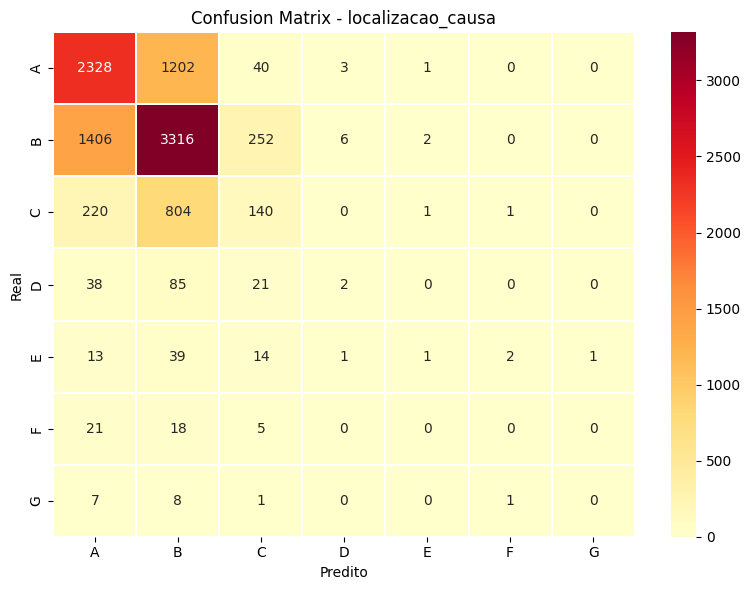

Ranking 2 - localizacao_estado_causa (9.07s)


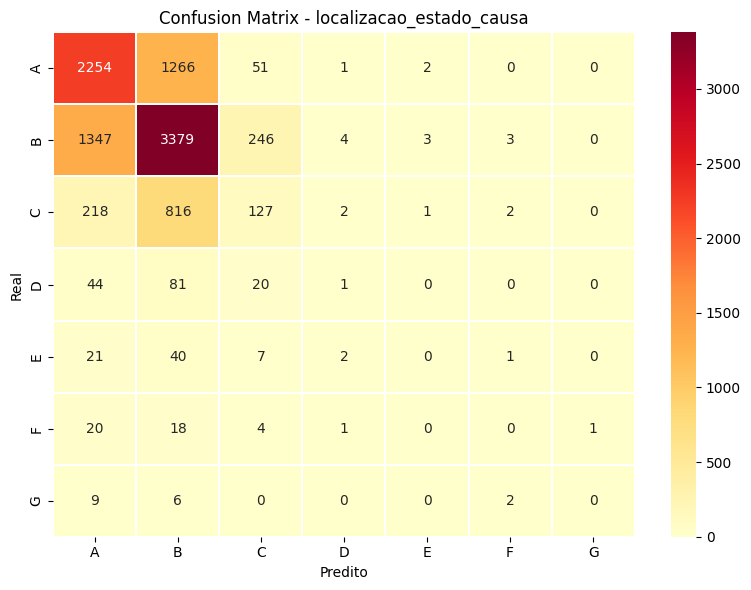

Ranking 3 - todos_sem_fire_size (9.72s)


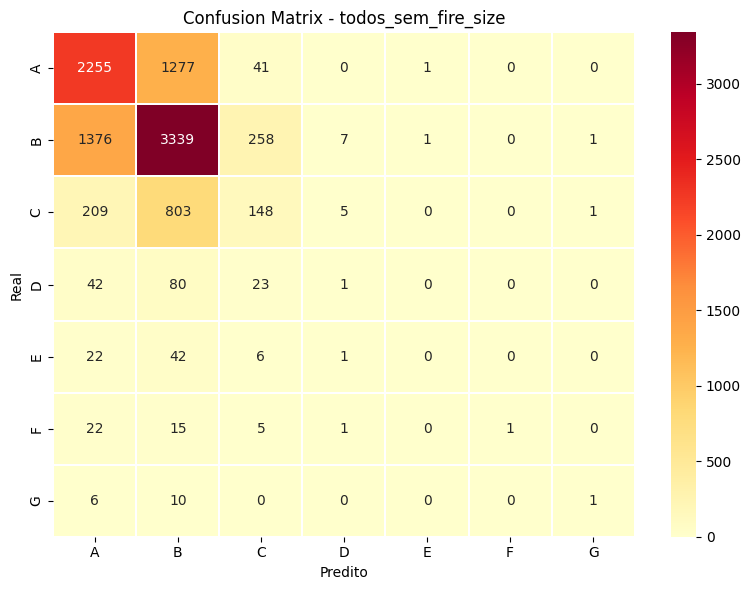

Ranking 4 - localizacao_estado (8.98s)


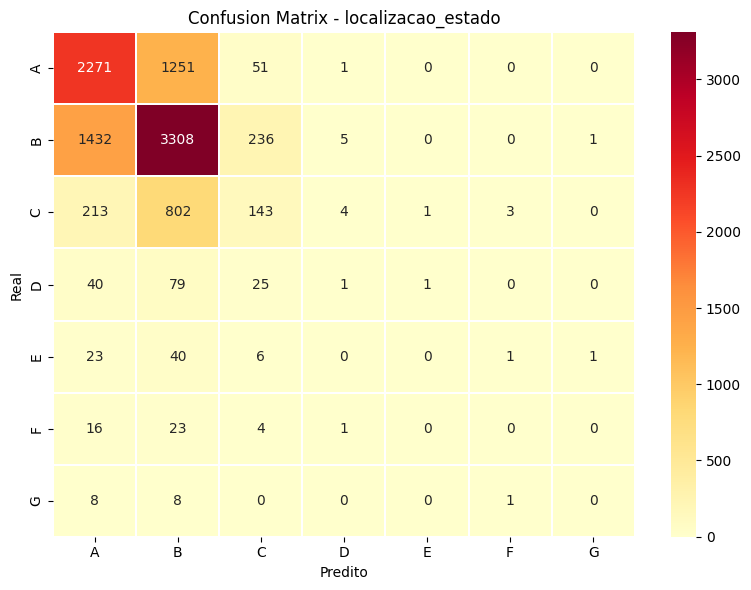

Ranking 5 - localizacao (0.27s)


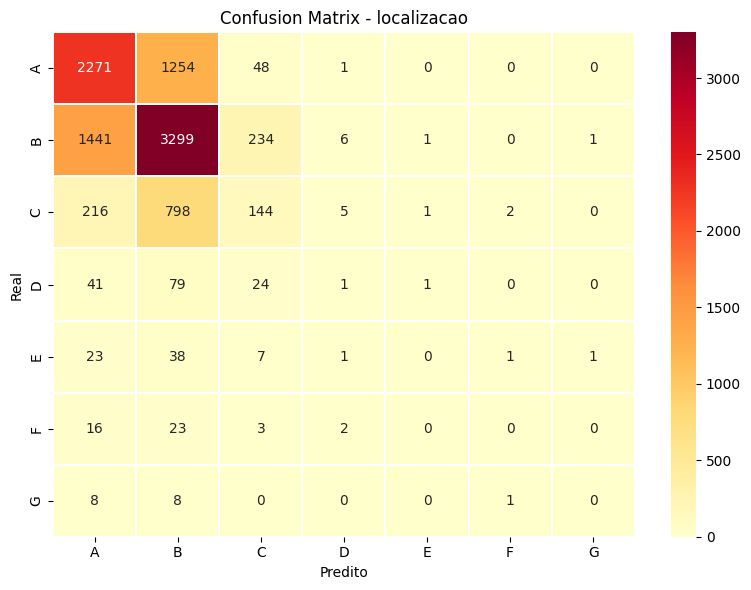

Ranking 6 - localizacao_estado_ano_diaAno (9.64s)


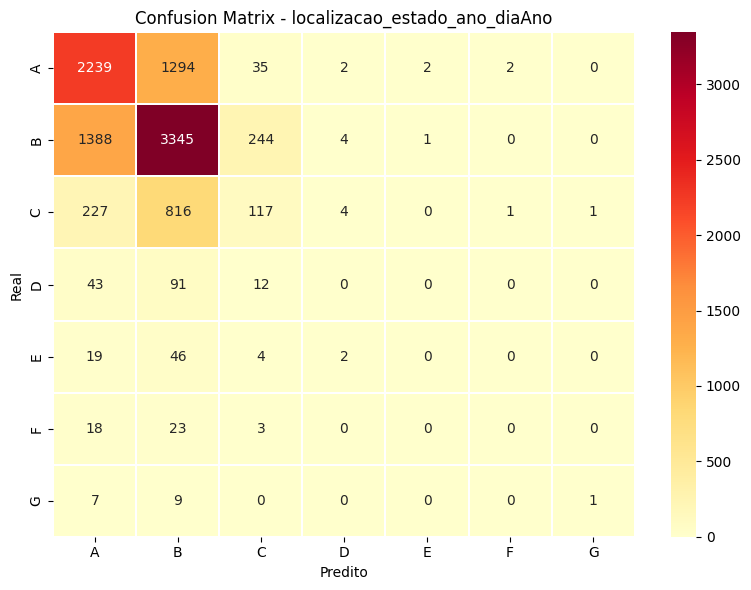

Ranking 7 - localizacao_tempo (0.14s)


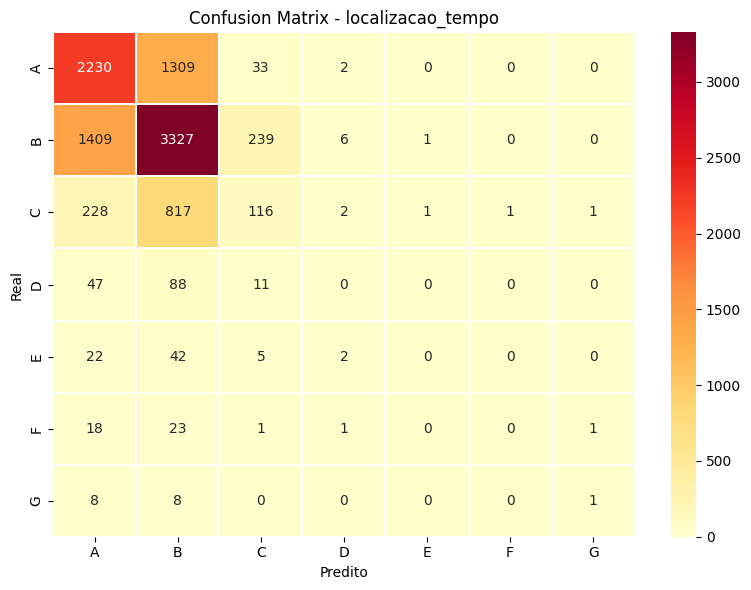

Ranking 8 - estado (4.19s)


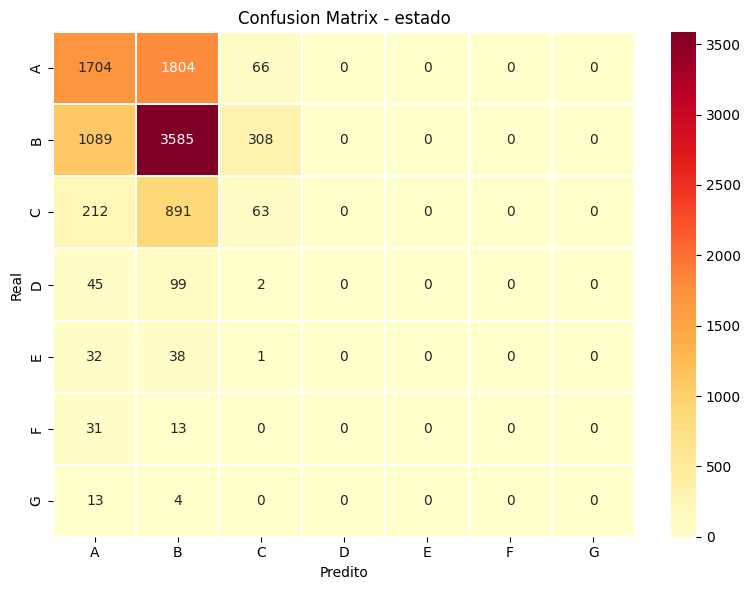

Ranking 9 - causa_estado (5.92s)


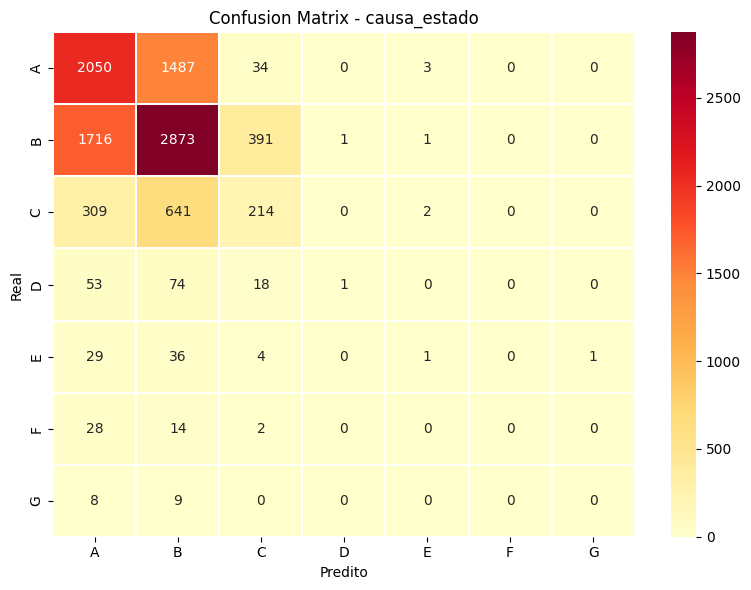

Ranking 10 - tempo (0.13s)


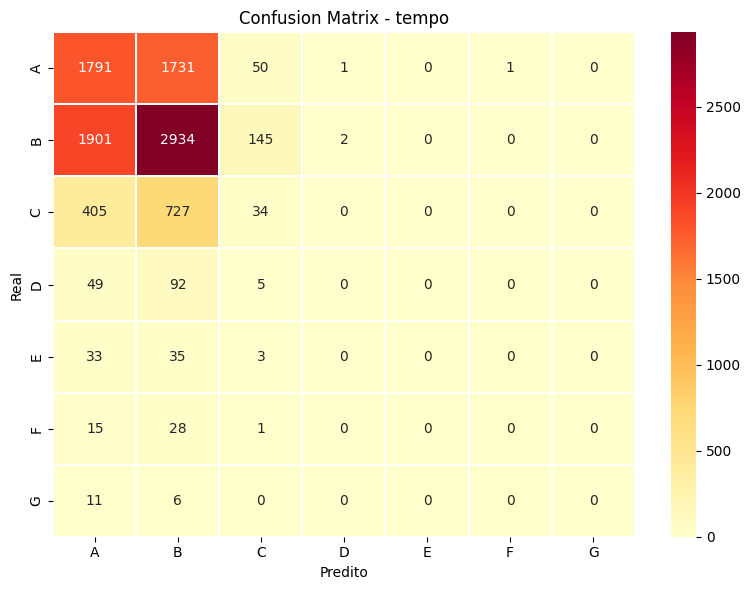

Ranking 11 - causa (5.08s)


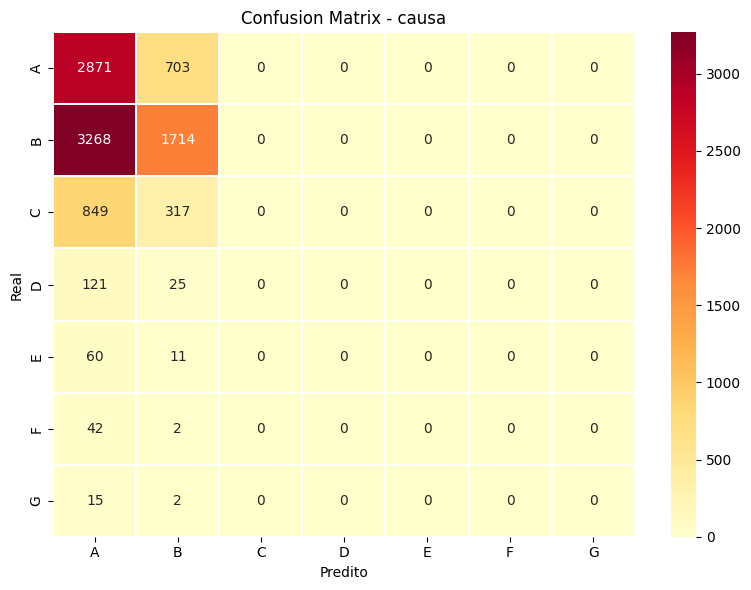


Melhor conjunto de features: localizacao_causa
Acuracia: 57.87%
F1-score: 0.5553
Tempo: 9.14s
Colunas usadas: ['LATITUDE', 'LONGITUDE', 'STAT_CAUSE_DESCR']


In [3]:
import time

# Treinamento do KNN, metodo classificado como Parte 1 da disciplina.
y_train = train_df[TARGET]
y_test = test_df[TARGET]

results = []
trained_models = {}
feature_names = list(FEATURES.keys())
elapsed_times = {}

for idx, (feature_name, feature_columns) in enumerate(FEATURES.items()):
    show_feature_loading_status(feature_names, idx, elapsed_times)

    start_time = time.perf_counter()

    model = create_pipeline(feature_columns, "knn")
    accuracy, cm, f1, labels = fit_accuracy_cm_f1(model, feature_columns)

    elapsed = time.perf_counter() - start_time
    elapsed_times[feature_name] = elapsed

    results.append(
        {
            "feature_set": feature_name,
            "accuracy": accuracy,
            "f1_score": f1,
            "tempo_segundos": elapsed,
            "confusion_matrix": cm,
            "labels": labels,
            "features": feature_columns,
        }
    )
    trained_models[feature_name] = model

    # Atualiza a tela movendo o item atual de em andamento para concluido.
    show_feature_loading_status(feature_names, idx + 1, elapsed_times)

results_df = show_model_ranking(results)
save_best_confusion_matrix(results_df, "KNN", "MelhorKnn.png")

best_feature_name = results_df.iloc[0]["feature_set"]
best_feature_columns = FEATURES[best_feature_name]
best_knn_model = trained_models[best_feature_name]

print()
print(f"Melhor conjunto de features: {best_feature_name}")
print(f"Acuracia: {results_df.iloc[0]['accuracy']:.2%}")
print(f"F1-score: {results_df.iloc[0]['f1_score']:.4f}")
print(f"Tempo: {results_df.iloc[0]['tempo_segundos']:.2f}s")
print(f"Colunas usadas: {best_feature_columns}")


Progresso por conjunto de features:

localizacao ✅ (1.63s)
localizacao_estado_ano_diaAno ✅ (10.84s)
localizacao_estado_causa ✅ (10.83s)
tempo ✅ (0.69s)
causa ✅ (0.34s)
estado ✅ (0.40s)
localizacao_tempo ✅ (2.15s)
localizacao_causa ✅ (10.64s)
localizacao_estado ✅ (11.01s)
causa_estado ✅ (0.86s)
todos_sem_fire_size ✅ (12.01s)


,ranking,feature_set,accuracy,f1_score,tempo
0,1,todos_sem_fire_size,61.19%,0.5865,12.01s
1,2,localizacao_estado_ano_diaAno,60.61%,0.5781,10.84s
2,3,localizacao_tempo,60.16%,0.5744,2.15s
3,4,causa_estado,59.94%,0.5522,0.86s
4,5,localizacao_estado_causa,59.68%,0.5737,10.83s
5,6,estado,59.19%,0.5458,0.40s
6,7,localizacao_causa,56.61%,0.5508,10.64s
7,8,localizacao,56.09%,0.5448,1.63s
8,9,localizacao_estado,55.80%,0.5433,11.01s
9,10,causa,54.70%,0.4766,0.34s



Matriz de confusão por ranking:

Ranking 1 - todos_sem_fire_size (12.01s)


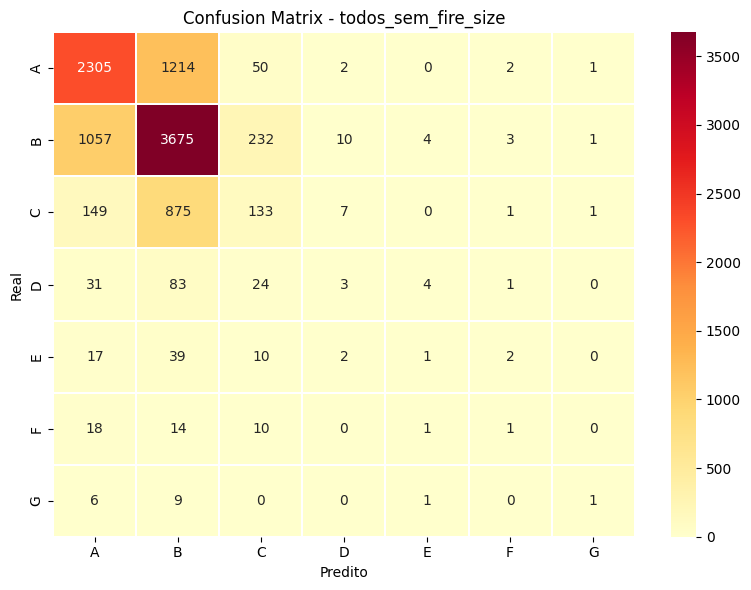

Ranking 2 - localizacao_estado_ano_diaAno (10.84s)


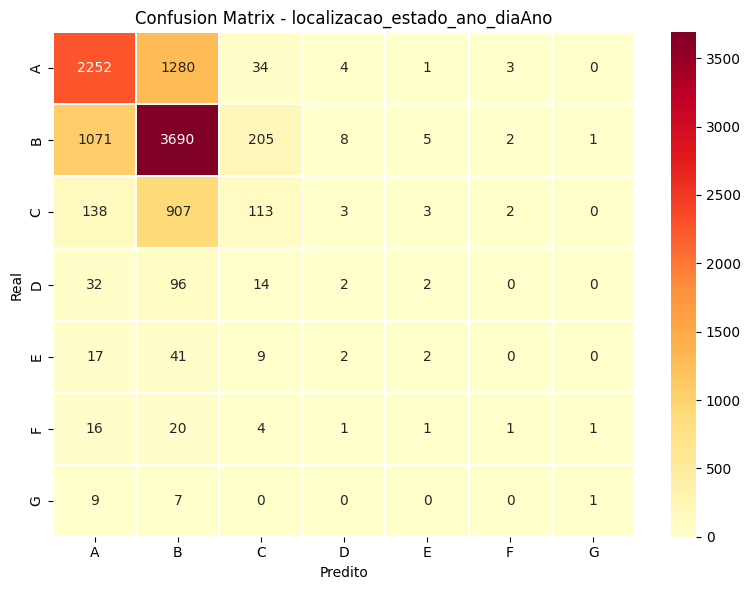

Ranking 3 - localizacao_tempo (2.15s)


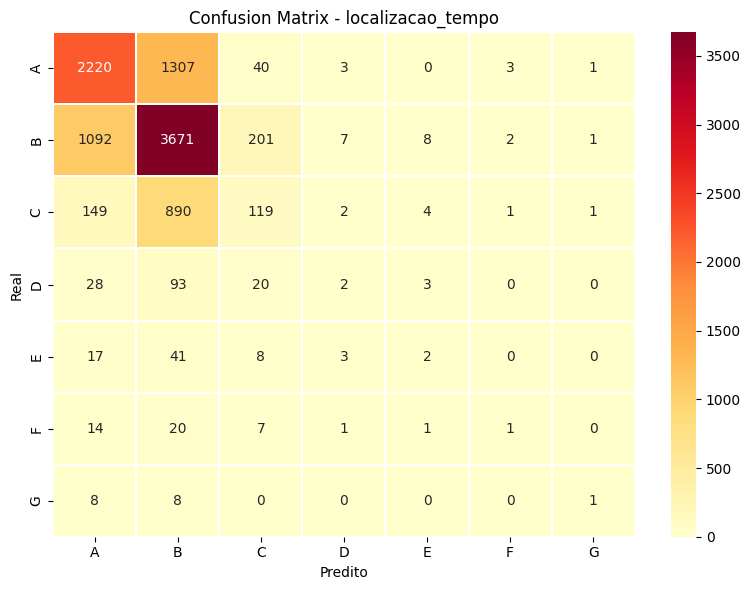

Ranking 4 - causa_estado (0.86s)


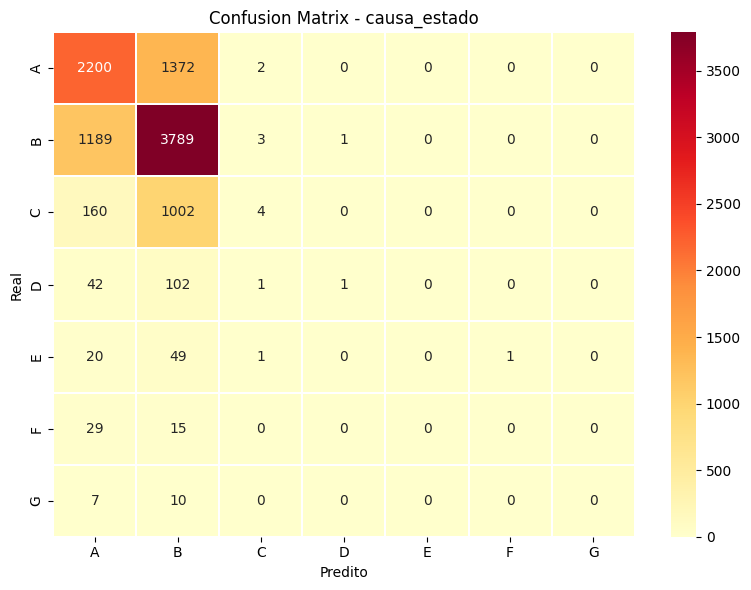

Ranking 5 - localizacao_estado_causa (10.83s)


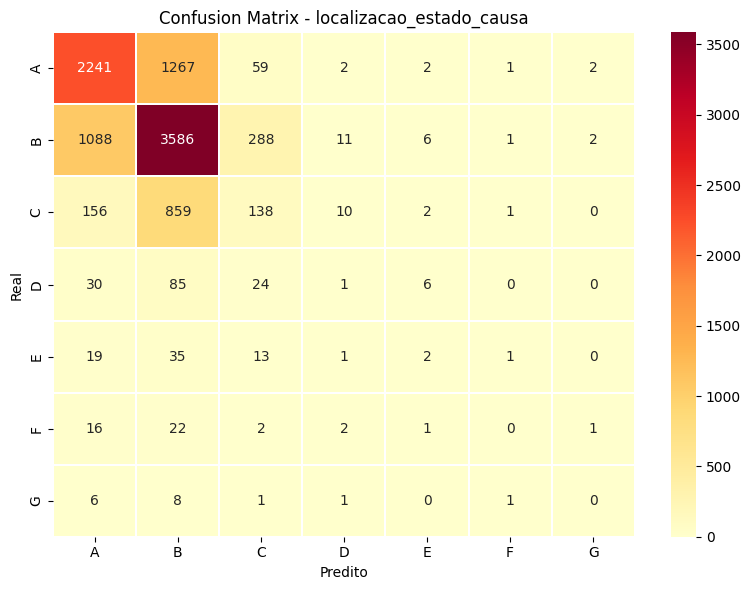

Ranking 6 - estado (0.40s)


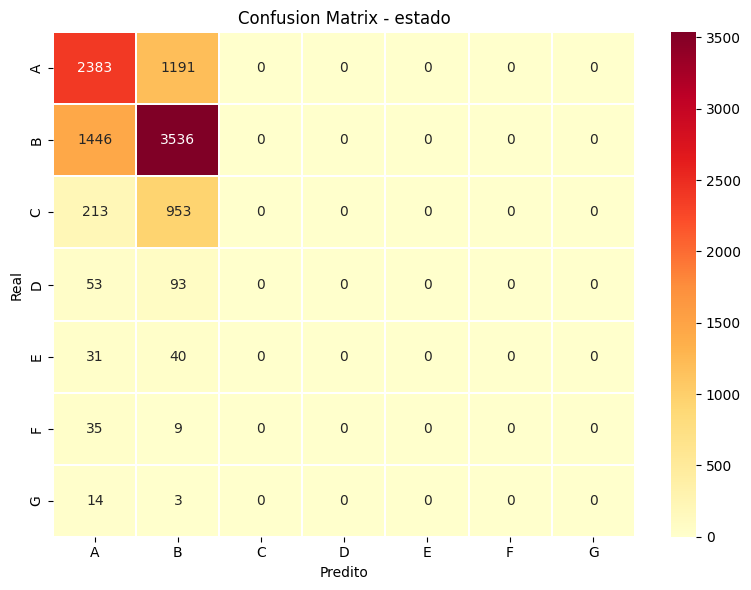

Ranking 7 - localizacao_causa (10.64s)


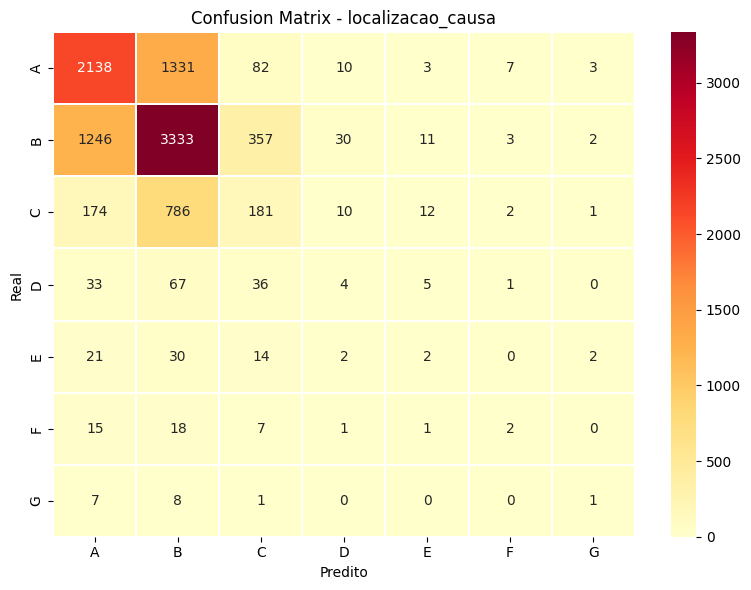

Ranking 8 - localizacao (1.63s)


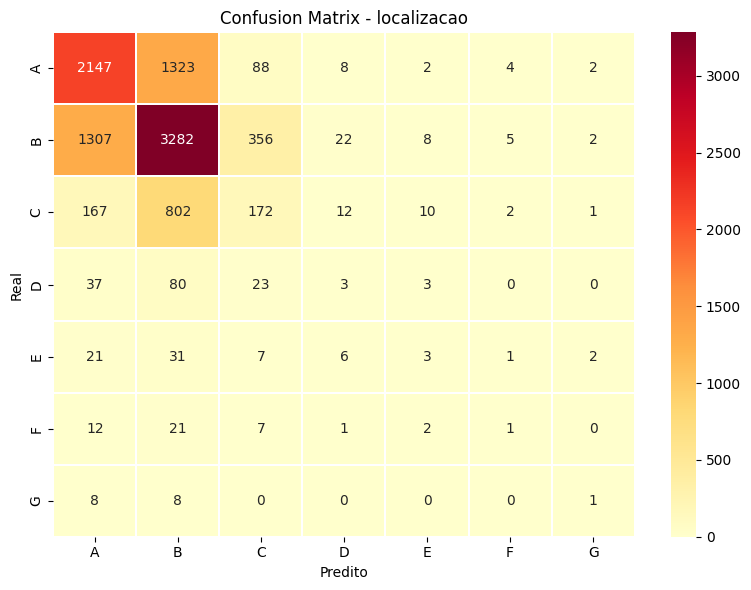

Ranking 9 - localizacao_estado (11.01s)


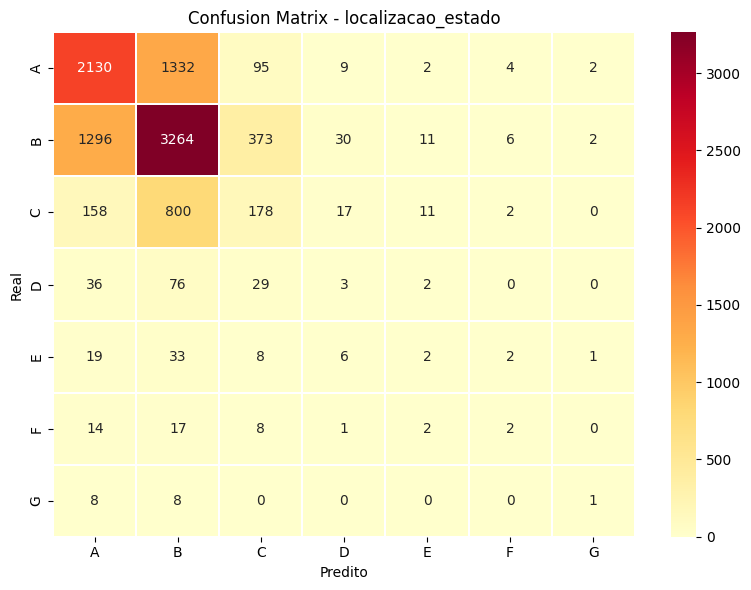

Ranking 10 - causa (0.34s)


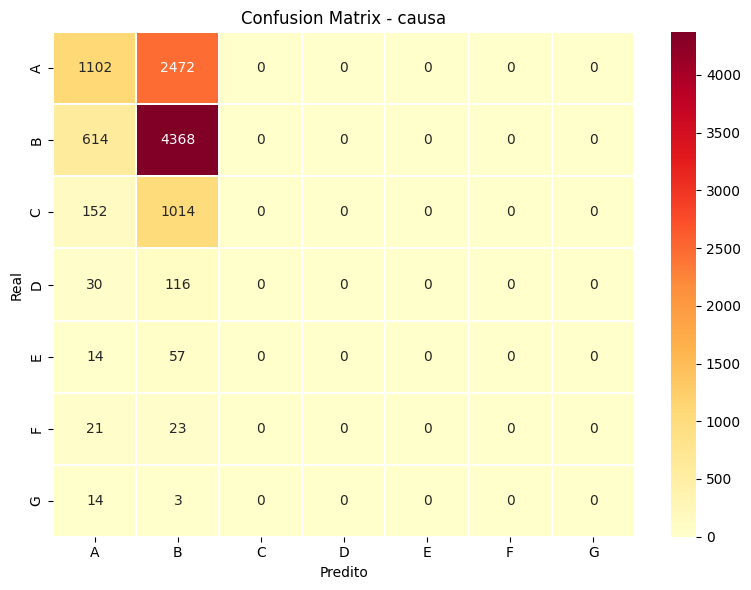

Ranking 11 - tempo (0.69s)


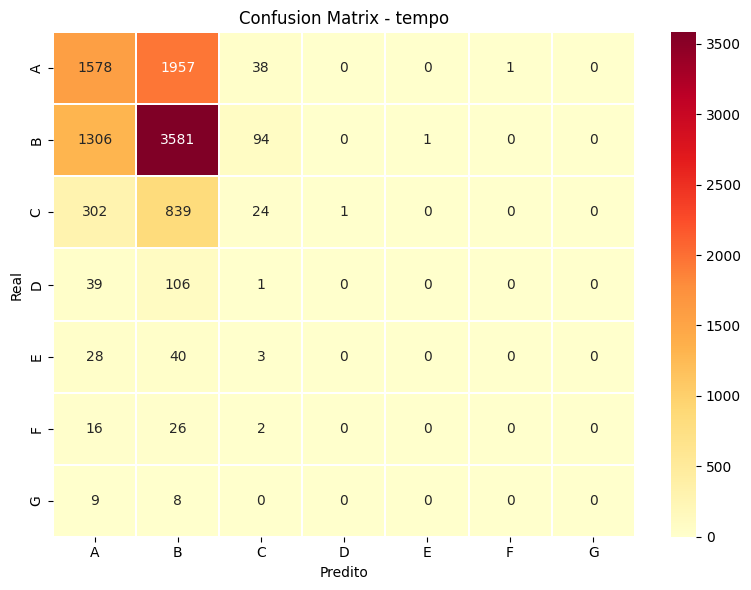


[RF] Melhor conjunto de features: todos_sem_fire_size
[RF] Acuracia: 61.19%
[RF] F1-score: 0.5865
[RF] Tempo: 12.01s
[RF] Colunas usadas: ['FIRE_YEAR', 'DISCOVERY_DOY', 'STAT_CAUSE_DESCR', 'LATITUDE', 'LONGITUDE', 'STATE']


In [4]:
import time

# Treinamento do Random Forest, metodo classificado como Parte 2 da disciplina.
y_train = train_df[TARGET]
y_test = test_df[TARGET]

results_rf = []
trained_models_rf = {}
feature_names = list(FEATURES.keys())
elapsed_times_rf = {}

for idx, (feature_name, feature_columns) in enumerate(FEATURES.items()):
    show_feature_loading_status(feature_names, idx, elapsed_times_rf)

    start_time = time.perf_counter()

    model_rf = create_pipeline(feature_columns, "rf")
    accuracy, cm, f1, labels = fit_accuracy_cm_f1(model_rf, feature_columns)

    elapsed = time.perf_counter() - start_time
    elapsed_times_rf[feature_name] = elapsed

    results_rf.append(
        {
            "feature_set": feature_name,
            "accuracy": accuracy,
            "f1_score": f1,
            "tempo_segundos": elapsed,
            "confusion_matrix": cm,
            "labels": labels,
            "features": feature_columns,
        }
    )
    trained_models_rf[feature_name] = model_rf

    show_feature_loading_status(feature_names, idx + 1, elapsed_times_rf)

results_rf_df = show_model_ranking(results_rf)
save_best_confusion_matrix(results_rf_df, "Random Forest", "MelhorRandomForest.png")

best_feature_name_rf = results_rf_df.iloc[0]["feature_set"]
best_feature_columns_rf = FEATURES[best_feature_name_rf]
best_rf_model = trained_models_rf[best_feature_name_rf]

print()
print(f"[RF] Melhor conjunto de features: {best_feature_name_rf}")
print(f"[RF] Acuracia: {results_rf_df.iloc[0]['accuracy']:.2%}")
print(f"[RF] F1-score: {results_rf_df.iloc[0]['f1_score']:.4f}")
print(f"[RF] Tempo: {results_rf_df.iloc[0]['tempo_segundos']:.2f}s")
print(f"[RF] Colunas usadas: {best_feature_columns_rf}")


Progresso por conjunto de features:

localizacao ✅ (2.65s)
localizacao_estado_ano_diaAno ✅ (4.50s)
localizacao_estado_causa ✅ (2.32s)
tempo ✅ (1.80s)
causa ✅ (1.18s)
estado ✅ (1.22s)
localizacao_tempo ✅ (2.92s)
localizacao_causa ✅ (2.86s)
localizacao_estado ✅ (2.84s)
causa_estado ✅ (1.50s)
todos_sem_fire_size ✅ (4.35s)


,ranking,feature_set,accuracy,f1_score,tempo
0,1,todos_sem_fire_size,61.32%,0.5701,4.35s
1,2,localizacao_estado_causa,61.20%,0.5620,2.32s
2,3,localizacao_estado_ano_diaAno,60.90%,0.5607,4.50s
3,4,localizacao_tempo,60.50%,0.5559,2.92s
4,5,causa_estado,59.90%,0.5516,1.50s
5,6,localizacao_estado,59.77%,0.5501,2.84s
6,7,localizacao_causa,59.76%,0.5481,2.86s
7,8,estado,59.31%,0.5470,1.22s
8,9,localizacao,59.29%,0.5457,2.65s
9,10,causa,54.70%,0.4766,1.18s



Matriz de confusão por ranking:

Ranking 1 - todos_sem_fire_size (4.35s)


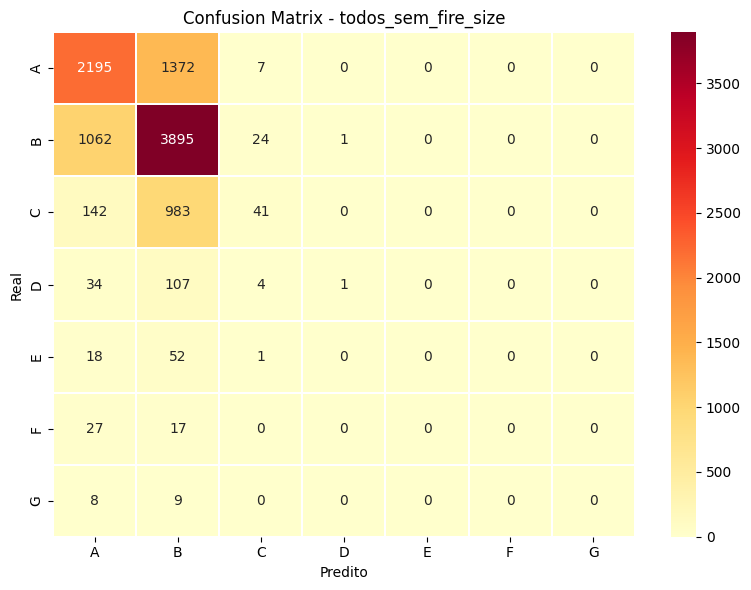

Ranking 2 - localizacao_estado_causa (2.32s)


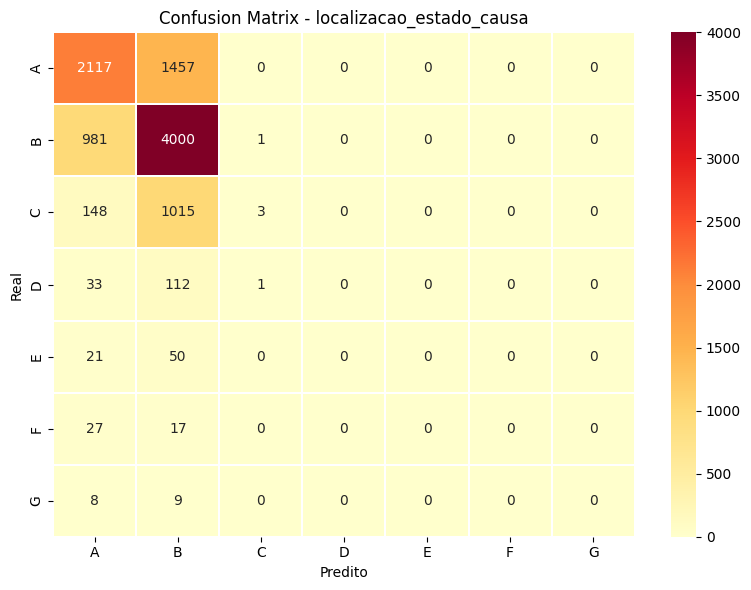

Ranking 3 - localizacao_estado_ano_diaAno (4.50s)


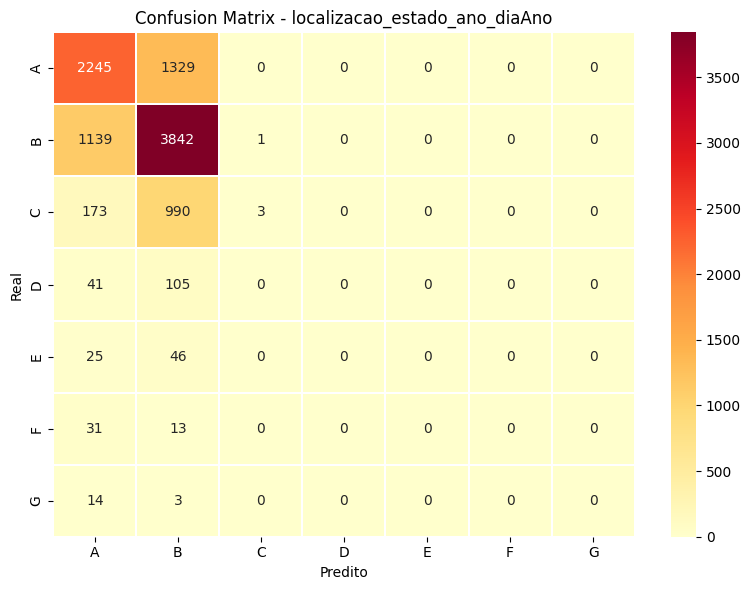

Ranking 4 - localizacao_tempo (2.92s)


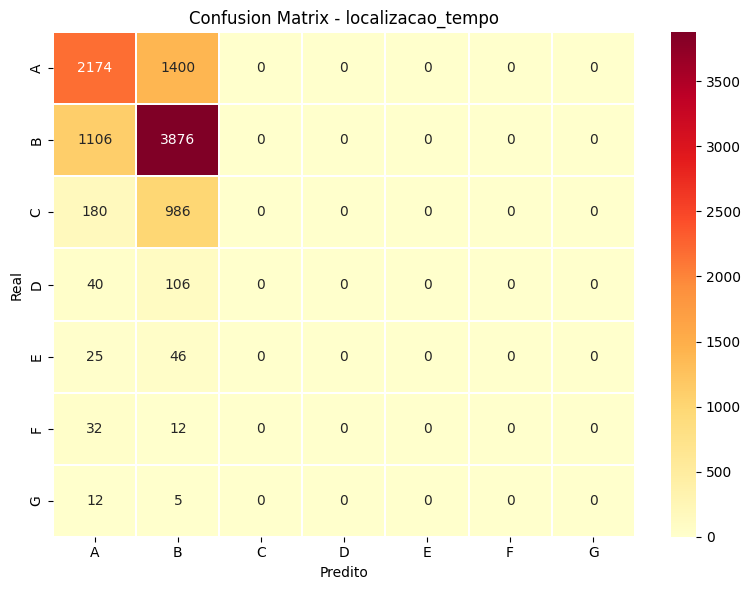

Ranking 5 - causa_estado (1.50s)


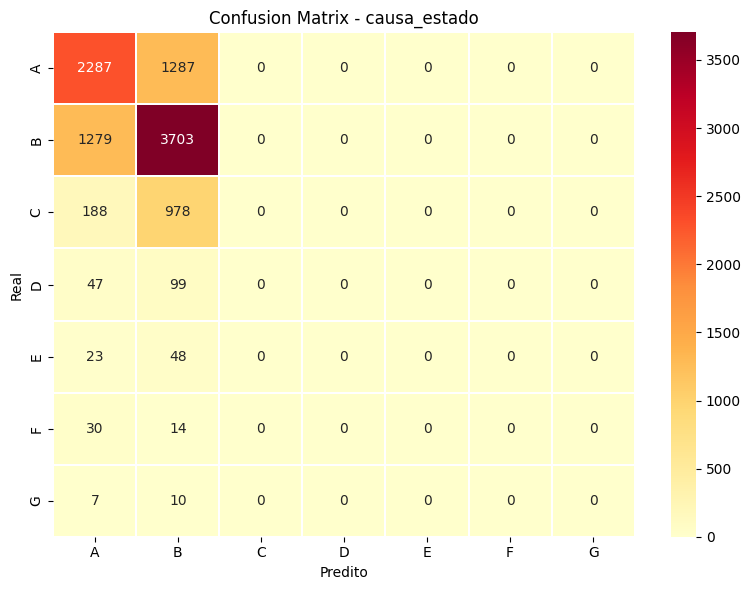

Ranking 6 - localizacao_estado (2.84s)


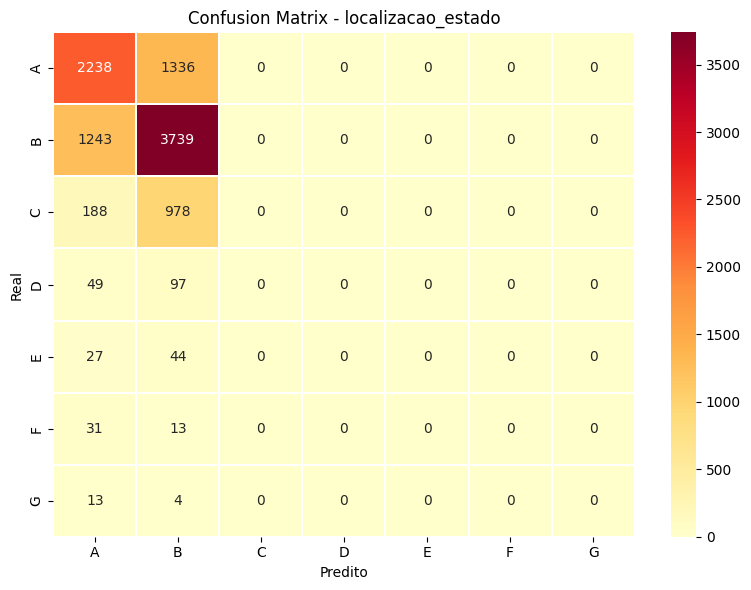

Ranking 7 - localizacao_causa (2.86s)


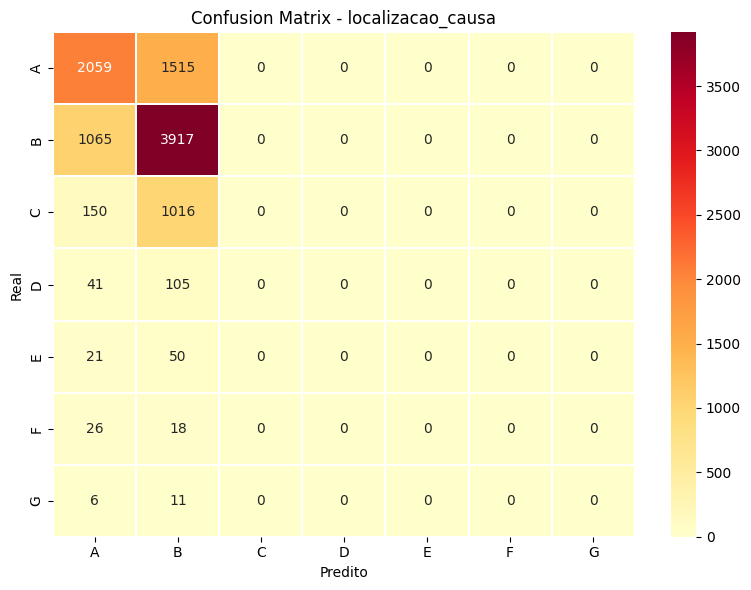

Ranking 8 - estado (1.22s)


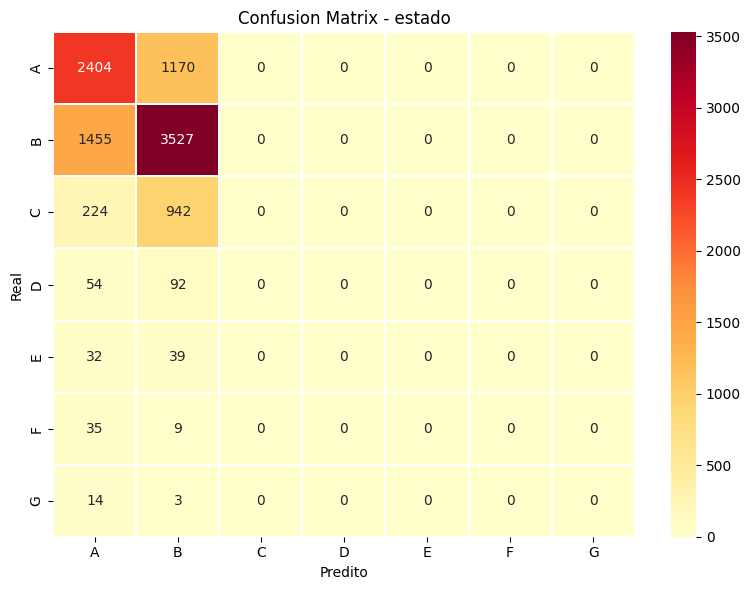

Ranking 9 - localizacao (2.65s)


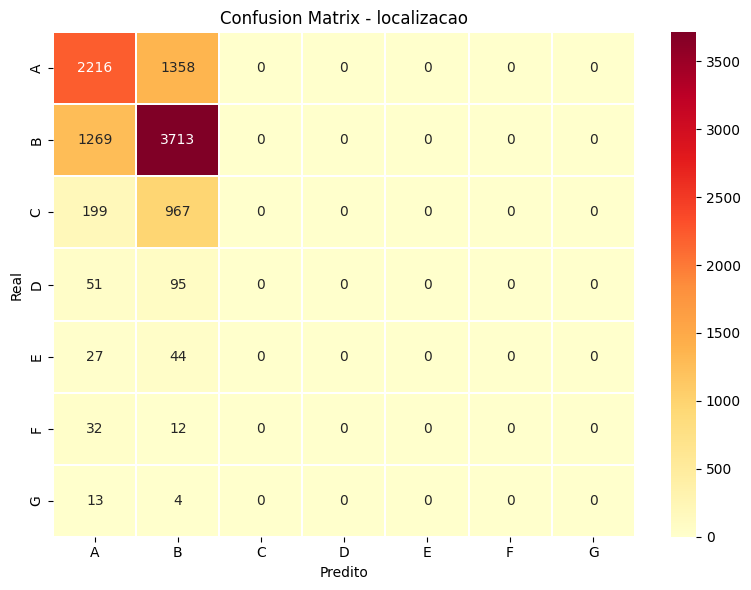

Ranking 10 - causa (1.18s)


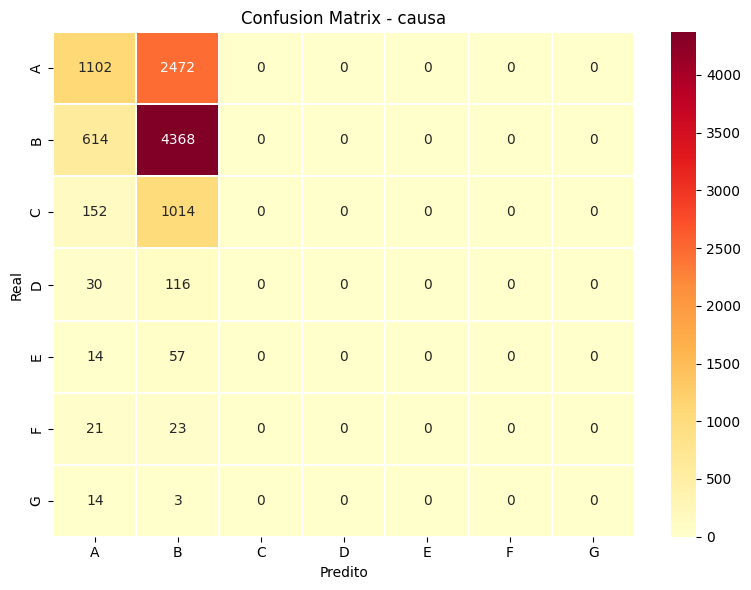

Ranking 11 - tempo (1.80s)


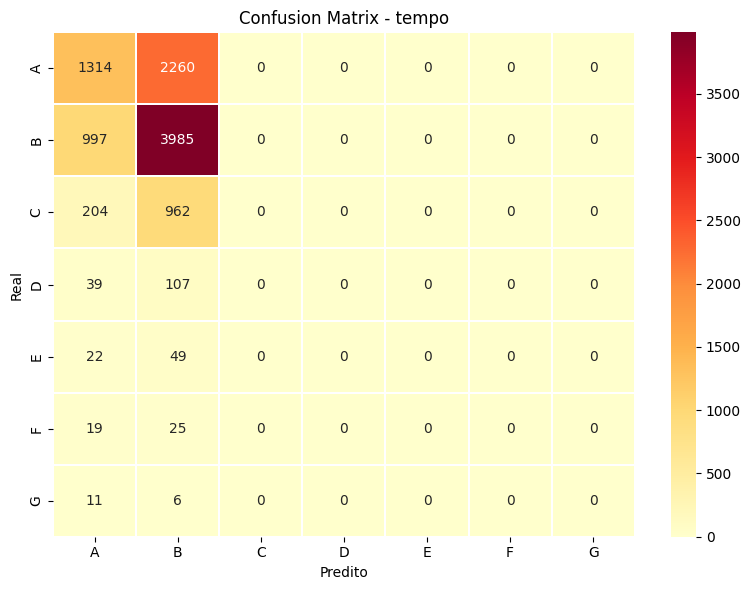

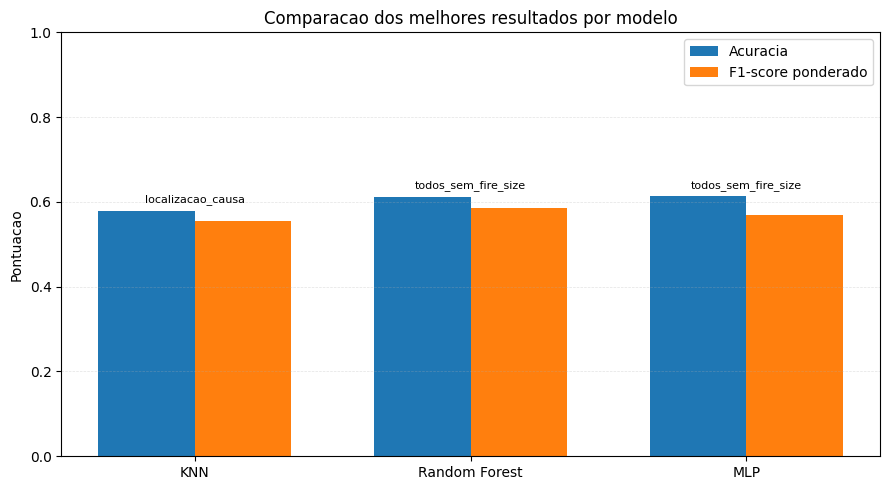


[MLP] Melhor conjunto de features: todos_sem_fire_size
[MLP] Acuracia: 61.32%
[MLP] F1-score: 0.5701
[MLP] Tempo: 4.35s
[MLP] Colunas usadas: ['FIRE_YEAR', 'DISCOVERY_DOY', 'STAT_CAUSE_DESCR', 'LATITUDE', 'LONGITUDE', 'STATE']


In [5]:
import time
from sklearn.preprocessing import LabelEncoder

# Treinamento do MLP, metodo classificado como Parte 2 da disciplina.
y_train = train_df[TARGET]
y_test = test_df[TARGET]

# MLP com early_stopping fica estavel com target numerico.
label_encoder = LabelEncoder()
y_train_mlp = label_encoder.fit_transform(y_train)
y_test_mlp = label_encoder.transform(y_test)

results_mlp = []
trained_models_mlp = {}
feature_names = list(FEATURES.keys())
elapsed_times_mlp = {}

for idx, (feature_name, feature_columns) in enumerate(FEATURES.items()):
    show_feature_loading_status(feature_names, idx, elapsed_times_mlp)

    start_time = time.perf_counter()

    model_mlp = create_pipeline(feature_columns, "mlp")
    accuracy, cm, f1, labels = fit_accuracy_cm_f1(
        model_mlp,
        feature_columns,
        y_train_input=y_train_mlp,
        y_test_input=y_test_mlp,
    )

    elapsed = time.perf_counter() - start_time
    elapsed_times_mlp[feature_name] = elapsed
    labels = label_encoder.inverse_transform(labels).tolist()


    results_mlp.append(
        {
            "feature_set": feature_name,
            "accuracy": accuracy,
            "f1_score": f1,
            "tempo_segundos": elapsed,
            "confusion_matrix": cm,
            "labels": labels,
            "features": feature_columns,
        }
    )
    trained_models_mlp[feature_name] = model_mlp

    show_feature_loading_status(feature_names, idx + 1, elapsed_times_mlp)

results_mlp_df = show_model_ranking(results_mlp)
save_best_confusion_matrix(results_mlp_df, "MLP", "MelhorMLP.png")
comparison_df = save_model_comparison(
    {
        "KNN": results_df,
        "Random Forest": results_rf_df,
        "MLP": results_mlp_df,
    }
)

best_feature_name_mlp = results_mlp_df.iloc[0]["feature_set"]
best_feature_columns_mlp = FEATURES[best_feature_name_mlp]
best_mlp_model = trained_models_mlp[best_feature_name_mlp]

print()
print(f"[MLP] Melhor conjunto de features: {best_feature_name_mlp}")
print(f"[MLP] Acuracia: {results_mlp_df.iloc[0]['accuracy']:.2%}")
print(f"[MLP] F1-score: {results_mlp_df.iloc[0]['f1_score']:.4f}")
print(f"[MLP] Tempo: {results_mlp_df.iloc[0]['tempo_segundos']:.2f}s")
print(f"[MLP] Colunas usadas: {best_feature_columns_mlp}")
